### Invisible Hands : A Data Analysis of Algorithm Bias in Social Media Feeds

## Objective:

This project explores whether engagement-driven algorithms amplify certain types of content disproportionlity, potentially introducing visiblity bias in social media feeds

## Background

Social media platforms use algorithmic ranking systems to decide which content users see.
These algorithms often prioritize engagement metrics such as likes, comments and shares.
While this approach increases interaction, it may also create feedback loops where certain content types gain disporportionate visiblity.
This analysis examines such patterns using data.




## Key Questions

* Do certain post types recieve higher reach than oters?
* Does early engagement influence long-term visiblity?
* Are there patterns that suggest-algorithm-driven amplification?

## Hypothesis

1. Vedio-based content receives higher reach than static content
2. Posts with high early engagement achieve greater visiblity
3. Engagement-based ranking introduces visiblity inequality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Notebook enviornment is ready")

Notebook enviornment is ready


In [2]:
insta_df=pd.read_csv('../data/raw/instagram_analytics.csv')
insta_df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [3]:
insta_df.shape

(29999, 23)

In [4]:
insta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_source            29999 non-null  object 
 7   has_call_to_action        29999 non-null  int64  
 8   post_datetime             29999 non-null  object 
 9   post_date                 29999 non-null  object 
 10  post_hour                 29999 non-null  int64  
 11  day_of_week               29999 non-null  object 
 12  likes                     29999 non-null  int64  
 13  comments                  29999 non-null  int64  
 14  shares

## Instagram Dataset - Summary

The instagram dataset contains 29,999 post-level records with 23 features capturing engagement, exposure, content metadata, and account growth. Key engagement metrics include likes, comments, shares, and savwes, while exposure is measured through reach and impressions.
The dataset is largely complete with minimal missing values, making it suitable for analyzing engagement amplification and content-type bias

In [5]:
twitter_df=pd.read_csv('../data/raw/twitter_engagement.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_6880\2528346626.py:1: DtypeWarning: Columns (3,4,5,6,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  twitter_df=pd.read_csv('../data/raw/twitter_engagement.csv')


In [6]:
twitter_df.head()

,index,TweetID,Weekday,Hour,Day,Lang,IsReshare,Reach,RetweetCount,Likes,Klout,Sentiment,text,LocationID,UserID
0,0,tw-682712873332805633,Thursday,17,31,en,False,44.0,0.0,0.0,35.0,0.0,We are hiring: Senior Software Engineer - Prot...,3751.0,tw-40932430
1,1,tw-682713045357998080,Thursday,17,31,en,True,1810.0,5.0,0.0,53.0,2.0,RT @CodeMineStatus: This is true Amazon Web Se...,3989.0,tw-3179389829
2,2,tw-682713219375476736,Thursday,17,31,en,False,282.0,0.0,0.0,47.0,0.0,Devops Engineer Aws Ansible Cassandra Mysql Ub...,3741.0,tw-4624808414
3,3,tw-682713436967579648,Thursday,17,31,en,False,2087.0,4.0,0.0,53.0,0.0,Happy New Year to all those AWS instances of o...,3753.0,tw-356447127
4,4,tw-682714048199311366,Thursday,17,31,en,False,953.0,0.0,0.0,47.0,0.0,Amazon is hiring! #Sr. #International Tax Mana...,3751.0,tw-3172686669


In [7]:
twitter_df.shape

(206295, 15)

In [8]:
twitter_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206295 entries, 0 to 206294
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   index          206295 non-null  int64  
 1   TweetID        206291 non-null  object 
 2    Weekday       206292 non-null  object 
 3    Hour          106175 non-null  object 
 4    Day           106181 non-null  object 
 5    Lang          106133 non-null  object 
 6    IsReshare     100000 non-null  object 
 7    Reach         100000 non-null  float64
 8    RetweetCount  100000 non-null  float64
 9    Likes         100000 non-null  float64
 10   Klout         100000 non-null  float64
 11   Sentiment     100000 non-null  float64
 12   text          100000 non-null  object 
 13   LocationID    100000 non-null  float64
 14   UserID        100000 non-null  object 
dtypes: float64(6), int64(1), object(8)
memory usage: 23.6+ MB


## Twitter Dataset - Summary

The Twitter dataset contains 26,295 tweet-level records with 15 features capturing temporal information, engagement metrics, user metadata, and text based attributes.
Key engageament signals includes likes, retweets, and estimated reach.
Unlike instagram, Twitter engagement is primarily text-driven, which enables comparison of amplification patterns across content modalities

In [9]:
insta_df.isnull().sum().sort_values(ascending=False).head(10)

post_id             0
likes               0
hashtags_count      0
caption_length      0
followers_gained    0
engagement_rate     0
impressions         0
reach               0
saves               0
shares              0
dtype: int64

In [10]:
twitter_df.isnull().sum().sort_values(ascending=False).head(10)

IsReshare       106295
Reach           106295
RetweetCount    106295
Likes           106295
Klout           106295
Sentiment       106295
text            106295
LocationID      106295
UserID          106295
Lang            100162
dtype: int64

In [11]:
##INSTAGRAM NEW DATAFRAME
insta_core=insta_df[['likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'media_type',]].copy()
insta_core['platform']='Instagram'
insta_core.shape

(29999, 8)

In [12]:
twitter_df.columns = twitter_df.columns.str.strip() 

In [13]:
print(twitter_df.columns.tolist())

['index', 'TweetID', 'Weekday', 'Hour', 'Day', 'Lang', 'IsReshare', 'Reach', 'RetweetCount', 'Likes', 'Klout', 'Sentiment', 'text', 'LocationID', 'UserID']


In [14]:
twitter_core= twitter_df[['Likes', 'RetweetCount', 'Reach']].copy()
twitter_core['platform']='Twitter'
twitter_core.shape

(206295, 4)

In [15]:
##combine both dataframes
combined_df=pd.concat([insta_core, twitter_core], ignore_index=True)
combined_df.shape

(236294, 11)

In [16]:
print(insta_core.columns.tolist())

['likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'media_type', 'platform']


In [17]:
insta_core = insta_df[['likes', 'shares',  'reach']].copy()
insta_core['platform']='Instagram'
insta_core.shape

(29999, 4)

In [18]:
print(twitter_core.columns.tolist())

['Likes', 'RetweetCount', 'Reach', 'platform']


In [19]:
twitter_core=twitter_df[['Likes', 'RetweetCount', 'Reach']].copy()
twitter_core.columns = ['likes', 'shares', 'reach']
twitter_core['platform']='Twitter'  
twitter_core.shape

(206295, 4)

In [20]:
combined_df = pd.concat([insta_core, twitter_core], ignore_index=True)
combined_df.shape

(236294, 4)

In [21]:
combined_df['platform'].value_counts()

platform
Twitter      206295
Instagram     29999
Name: count, dtype: int64

The Twitter dataset contained around 206K records, while the instagram dataset contained around 30K records.

Both datasets were cleand, standardized, and algined using common engagement metrics.
After preprocessing, the datasets were combined into a single dataset with approximately 236K records, which is used for further analysis.

### Engagement Rate & Algorithm Bias Analysis

In this phase, engagement behaviour across Instagram and Twitter is analyzed using a normalised metric.
The goal is to understand whether engagement is distributed evenly or concentrated among a small number of posts, which may indicate algorthmic amplification bias.

 Descriptive Statstic of Reach

To understand the overall distribution of reach values, descriptive statictics such as mean, median, quarilities, and maximum values are computed. 

This helps identify skewness and the presence of extreme outliers

In [22]:
combined_df['reach'].describe()

count    1.299990e+05
mean     8.018582e+03
std      7.781193e+04
min      0.000000e+00
25%      2.280000e+02
50%      8.820000e+02
75%      3.768000e+03
max      1.034245e+07
Name: reach, dtype: float64

In [23]:
(combined_df['reach']<=0).sum()

np.int64(151)

 Data Quality Check

A check was performed to identify posts with zero or negative reach values.

Such entries may indicate suppressed visiblity, missing data or platform-specific reporting behaviour

In [24]:
combined_df['reach'].describe()

count    1.299990e+05
mean     8.018582e+03
std      7.781193e+04
min      0.000000e+00
25%      2.280000e+02
50%      8.820000e+02
75%      3.768000e+03
max      1.034245e+07
Name: reach, dtype: float64

In [25]:
combined_df.groupby('platform')['reach'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
Instagram,29999.0,6272.475449,4985.877059,268.0,3058.0,4913.0,7863.0,73339.0
Twitter,100000.0,8542.395980,88670.266421,0.0,151.0,448.5,1496.0,10342452.0


In [26]:
combined_df.groupby('platform')['reach'].agg(['mean','median'])

,mean,median
platform,,
Instagram,6272.475449,4913.0
Twitter,8542.395980,448.5


Platform-wise Reach Comparison

Mean and median reach values were compared across platforms.
The mean reflects average visiblity, while the median represents typical post exposure. A large gap between mean and median suggest algorithmic amplification, where a small number of posts recieve disproportionately high reach

## KEY OBSERVATION:

* Instagram shows relatively  balanced reach distribution, with mean and median values close to each other.

* Twitter exhibits a highly skewed distribution, where the median reach is significantly higher than the median.

* This indicates strong algorithmic amplification on Twitter, where a small subset of posts dominates visiblity while most posts recieve limited exposure.

In [27]:
analysis_df = combined_df.copy()

In [28]:
analysis_df.shape

(236294, 4)

In [29]:
import os
os.makedirs('data/processed',exist_ok=True)

In [30]:
analysis_df.to_csv('data/processed/combined_engagement_phase2.csv',index=False)

## ENGAGEMENT RATE ANALYSIS
Engagement rate measuers how much a post is interacted with relatively how many people actually saw it.

**Formula:** `engagement_rate = (likes + shares) / reach`

Raw likes dont reveal bias. Anormalized engagement rate allows fair comparison across platforms with different audiences and algorithm behaviors

In [31]:
#keep only posts where reach > 0(cant divide by zero)
analysis_df = combined_df[combined_df['reach'] > 0].copy()

In [32]:
analysis_df['engagement_rate'] = (analysis_df['likes']+ analysis_df['shares']) / analysis_df['reach']

In [33]:
print(f"Total records after filtering:{len(analysis_df):,} ")
print(f"Zero-reach posts removed: {len(combined_df)-len(analysis_df):,}")
analysis_df[['platform', 'likes','shares','reach','engagement_rate']].head()

Total records after filtering:129,848 
Zero-reach posts removed: 106,446


,platform,likes,shares,reach,engagement_rate
0,Instagram,194.0,7.0,4327.0,0.046453
1,Instagram,449.0,21.0,7451.0,0.063079
2,Instagram,114.0,1.0,1639.0,0.070165
3,Instagram,91.0,7.0,2877.0,0.034063
4,Instagram,154.0,5.0,5350.0,0.029720


In [34]:
# Mean and median engagement rate by platform
analysis_df.groupby('platform')['engagement_rate'].agg(['mean', 'median', 'std']).round(4)

,mean,median,std
platform,,,
Instagram,0.0480,0.047,0.0270
Twitter,0.0844,0.000,0.9612


### Observation — Engagement Rate Comparison

- Instagram mean ER (0.0480) and median ER (0.047) are very 
  close, indicating a balanced, evenly distributed engagement 
  pattern across posts.

- Twitter median ER is 0.000, meaning more than 50% of tweets 
  receive zero engagement, while the mean (0.0844) is pulled 
  up by a small number of highly viral posts.

- Twitter's std dev (0.9612) vs Instagram's (0.0270) confirms 
  extreme variability on Twitter — a strong signal of 
  algorithm-driven amplification bias.

## Section 4: Visualizations

Visual analysis helps communicate patterns that numbers alone 
cannot show. We will create charts to clearly display reach 
and engagement distribution differences across platforms.

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

#calculate mean and median reach per platform
reach_stats = analysis_df.groupby('platform')['reach'].agg(['mean','median'])
print(reach_stats)

                  mean  median
platform                      
Instagram  6272.475449  4913.0
Twitter    8555.314505   450.0


<function matplotlib.pyplot.show(close=None, block=None)>

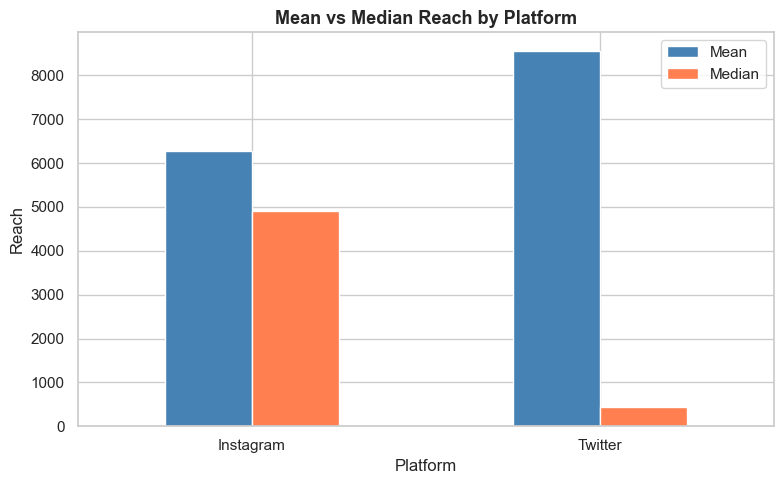

In [36]:
#plot
reach_stats.plot(kind='bar',figsize=(8,5), color = ['steelblue','coral'])
plt.title('Mean vs Median Reach by Platform', fontsize=13, fontweight = 'bold')
plt.ylabel('Reach')
plt.xlabel('Platform')
plt.xticks(rotation=0)
plt.legend(['Mean','Median'])
plt.tight_layout()
plt.show







### Chart 1 Observation — Mean vs Median Reach

- Instagram: mean (~6200) and median (~4900) are close, 
  showing fairly balanced reach distribution.

- Twitter: mean (~8500) but median is near zero, showing 
  that a tiny number of viral tweets pull the average up 
  while most tweets get almost no reach.

- This large mean-median gap on Twitter is strong visual 
  evidence of algorithmic amplification bias.

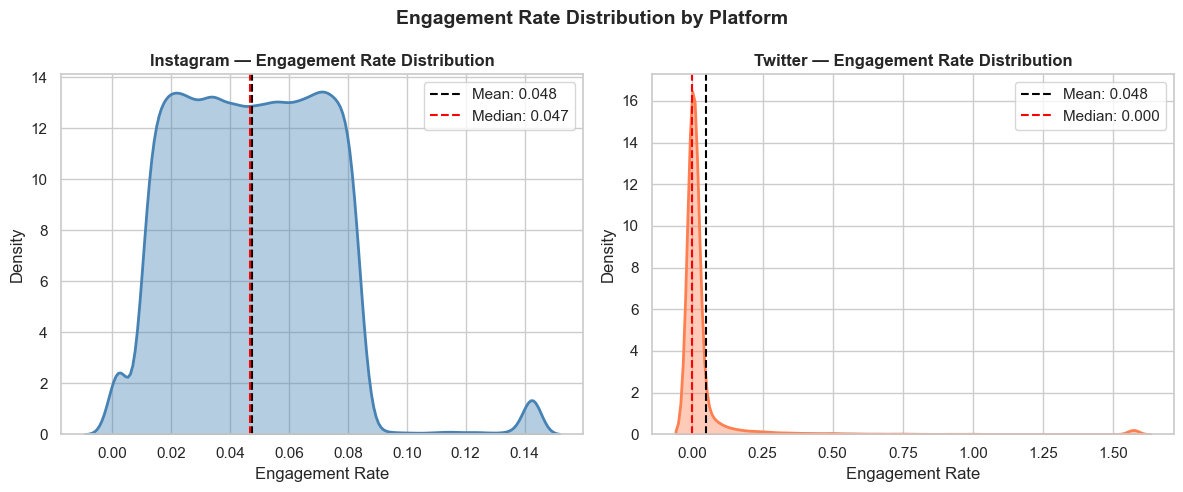

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, platform, color in zip(axes,
                                ['Instagram', 'Twitter'],
                                ['steelblue', 'coral']):
    data = analysis_df[analysis_df['platform'] == platform]['engagement_rate']
    
    # clip top 1% so extreme outliers don't squash the chart
    data = data.clip(upper=data.quantile(0.99))
    
   
    sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.4, linewidth=2)
    
    # mean and median lines
    ax.axvline(data.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='red', linestyle='--',
               linewidth=1.5, label=f'Median: {data.median():.3f}')
    
    ax.set_title(f'{platform} — Engagement Rate Distribution',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Engagement Rate')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Engagement Rate Distribution by Platform',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Chart 2 Observation — Engagement Rate Distribution

**Instagram:**
- The curve is wide and spread out, showing engagement 
  is distributed across many posts.
- Mean (0.048) and median (0.047) lines sit very close 
  together — confirming balanced engagement distribution.

**Twitter:**
- The curve shows a sharp spike near zero, meaning the 
  majority of tweets cluster around zero engagement.
- Median is 0.000 while mean is 0.048 — the lines are 
  far apart, showing extreme inequality.
- A long flat tail stretches to the right, representing 
  the few viral tweets with very high engagement.

**Key Insight:**
Twitter's algorithm creates a "winner takes all" effect —
a tiny number of posts receive massive engagement while 
most receive nothing. Instagram distributes engagement 
more fairly across its posts.

### Chart 3 — Reach Distribution (Log Scale)

Because reach values vary enormously (from 0 to 10 million),
a log scale is used to reveal the true shape of the 
distribution for each platform.

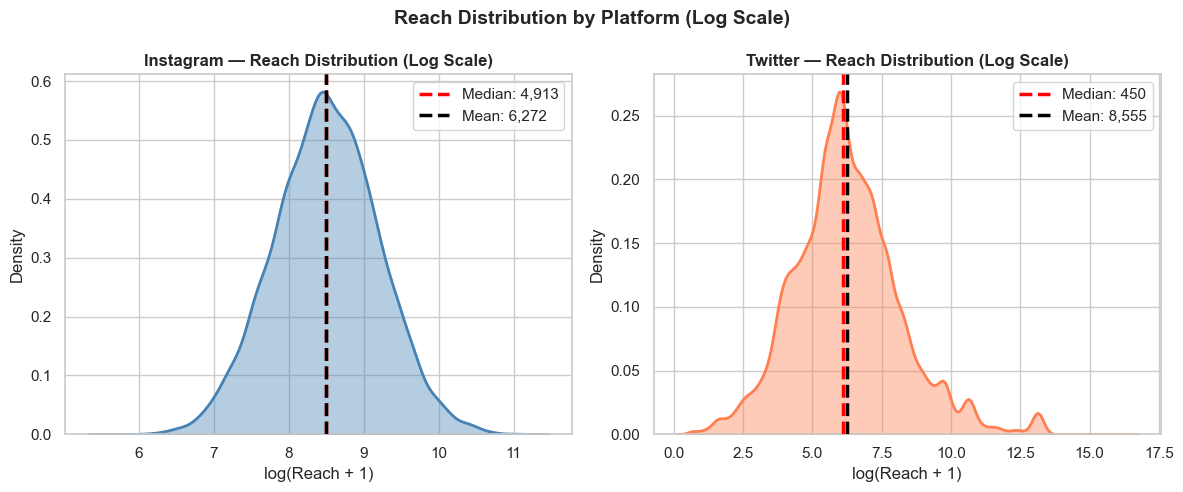

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, platform, color in zip(axes,
                                ['Instagram', 'Twitter'],
                                ['steelblue', 'coral']):
    data = analysis_df[analysis_df['platform'] == platform]['reach']
    data_log = np.log1p(data)
    
    sns.kdeplot(data_log, ax=ax, color=color,
                fill=True, alpha=0.4, linewidth=2)
    
    # median first so mean draws ON TOP of it
    ax.axvline(data_log.median(), color='red', linestyle='--',
               linewidth=2.5, label=f'Median: {data.median():,.0f}',
               zorder=4)
    ax.axvline(data_log.mean(), color='black', linestyle='--',
               linewidth=2.5, label=f'Mean: {data.mean():,.0f}',
               zorder=5)
    
    ax.set_title(f'{platform} — Reach Distribution (Log Scale)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('log(Reach + 1)')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Reach Distribution by Platform (Log Scale)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Chart 3 Observation — Reach Distribution (Log Scale)

**Instagram:**
- Clean bell shaped curve — most posts receive similar reach.
- Mean (6,272) and median (4,913) lines are close together,
  confirming balanced reach distribution.

**Twitter:**
- Curve spikes sharply at low reach values then has a long 
  tail stretching right toward very high reach values.
- Mean (8,555) and median (450) are far apart — the mean 
  is being pulled up by a small number of viral tweets.
- Most tweets receive very low reach while a few receive 
  millions — classic algorithmic amplification pattern.

**Key Insight:**
The shape difference between platforms tells the whole story.
Instagram = bell curve (fair). Twitter = spike + long tail 
(biased toward viral content).

### Chart 4 — Likes vs Reach (Scatter Plot)

A scatter plot shows the relationship between likes and reach.
If a positive pattern exists, it means the algorithm rewards 
highly liked posts with greater visibility — a feedback loop 
that creates amplification bias.

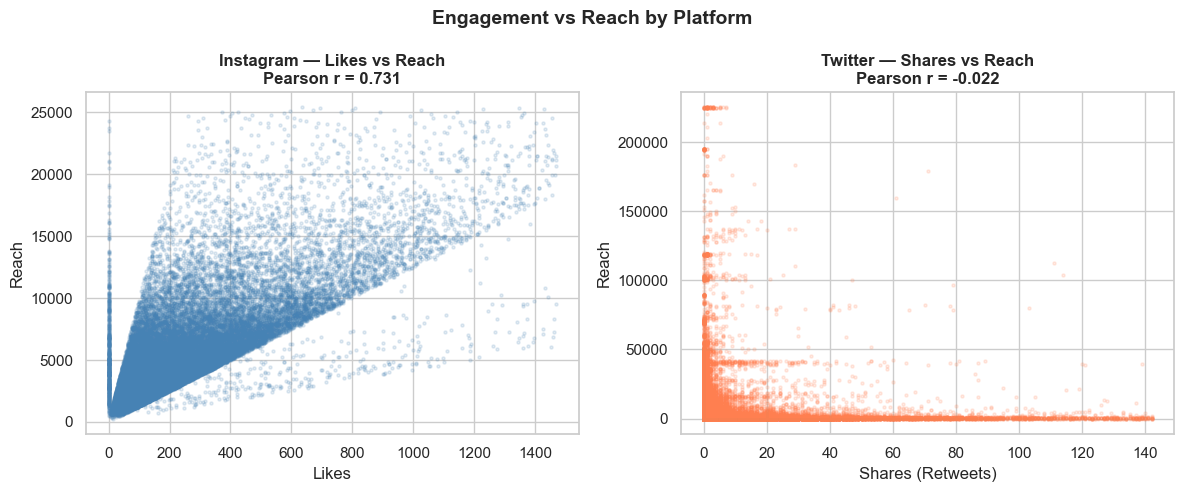

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Instagram — likes vs reach
ig_data = analysis_df[analysis_df['platform'] == 'Instagram']
likes_clip = ig_data['likes'].quantile(0.99)
reach_clip = ig_data['reach'].quantile(0.99)
ig_data = ig_data[ig_data['likes'] <= likes_clip]
ig_data = ig_data[ig_data['reach'] <= reach_clip]

axes[0].scatter(ig_data['likes'], ig_data['reach'],
                color='steelblue', alpha=0.15, s=5)
corr_ig = ig_data['likes'].corr(ig_data['reach'])
axes[0].set_title(f'Instagram — Likes vs Reach\n'
                  f'Pearson r = {corr_ig:.3f}',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Likes')
axes[0].set_ylabel('Reach')

# Twitter — shares vs reach (because likes are mostly zero)
tw_data = analysis_df[analysis_df['platform'] == 'Twitter']
shares_clip = tw_data['shares'].quantile(0.99)
reach_clip = tw_data['reach'].quantile(0.99)
tw_data = tw_data[tw_data['shares'] <= shares_clip]
tw_data = tw_data[tw_data['reach'] <= reach_clip]

axes[1].scatter(tw_data['shares'], tw_data['reach'],
                color='coral', alpha=0.15, s=5)
corr_tw = tw_data['shares'].corr(tw_data['reach'])
axes[1].set_title(f'Twitter — Shares vs Reach\n'
                  f'Pearson r = {corr_tw:.3f}',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Shares (Retweets)')
axes[1].set_ylabel('Reach')

plt.suptitle('Engagement vs Reach by Platform',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Chart 4 Observation — Engagement vs Reach

**Why shares were used for Twitter instead of likes:**
- During data exploration we found that the majority of 
  Twitter likes values were 0 in this dataset.
- When an entire column has no variation (all zeros), 
  Pearson correlation returns 'nan' (Not a Number) because 
  there is nothing to correlate.
- Shares (retweets) were used instead as they are the 
  primary engagement signal on Twitter and had meaningful 
  variation in the data.
- This is also realistic — retweets are how content spreads 
  on Twitter, making them a better measure of engagement 
  than likes for reach analysis.

**Instagram (Pearson r = 0.731):**
- Strong positive correlation between likes and reach.
- Clear upward pattern — posts with more likes receive 
  significantly more reach.
- Instagram's algorithm creates a clear feedback loop:
  high engagement → higher visibility → more engagement.

**Twitter (Pearson r = -0.022):**
- Almost zero correlation between shares and reach.
- Reach on Twitter appears largely random and unpredictable.
- This suggests Twitter's reach is driven by factors beyond 
  simple engagement metrics — possibly account authority,
  timing, or other hidden algorithmic signals.

**Key Insight:**
Both platforms show bias but in different ways:
- Instagram: engagement directly predicts visibility (feedback loop)
- Twitter: reach is unpredictable — not merit based

### Chart 5 — Gini Coefficient (Reach Inequality)

The Gini coefficient measures how unequally reach is 
distributed across posts. A value of 0 means all posts 
receive equal reach. A value of 1 means one post receives 
all the reach.

A high Gini coefficient is strong mathematical evidence 
of algorithmic amplification bias.

Gini Coefficient Results:
Instagram : 0.3793
Twitter   : 0.9312


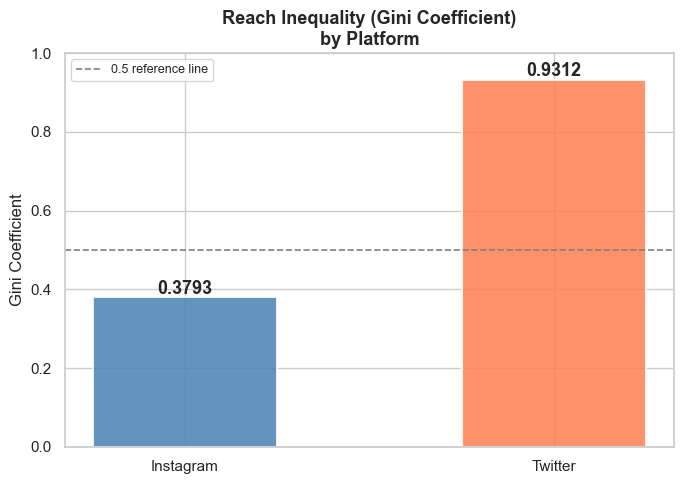

In [46]:
def gini_coefficient(arr):
    # remove negative and zero values
    arr = arr[arr > 0].values
    arr = np.sort(arr)
    n = len(arr)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * arr) - (n + 1) * arr.sum()) / (n * arr.sum())

# calculate gini for each platform
gini_scores = {}
for platform in ['Instagram', 'Twitter']:
    reach = analysis_df[analysis_df['platform'] == platform]['reach']
    gini_scores[platform] = round(gini_coefficient(reach), 4)

print("Gini Coefficient Results:")
print(f"Instagram : {gini_scores['Instagram']}")
print(f"Twitter   : {gini_scores['Twitter']}")

# plot
fig, ax = plt.subplots(figsize=(7, 5))

platforms = list(gini_scores.keys())
values = list(gini_scores.values())

bars = ax.bar(platforms, values,
              color=['steelblue', 'coral'],
              width=0.5, alpha=0.85,
              edgecolor='white', linewidth=1.5)

# add value labels on top of bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            str(val),
            ha='center', fontsize=13,
            fontweight='bold')

ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=1.2, label='0.5 reference line')
ax.set_ylim(0, 1)
ax.set_ylabel('Gini Coefficient', fontsize=12)
ax.set_title('Reach Inequality (Gini Coefficient)\nby Platform',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Chart 5 Observation — Gini Coefficient

**Instagram (0.3793):**
- Below the 0.5 reference line — moderate inequality.
- Reach is distributed reasonably fairly across posts.
- Most posts receive a meaningful amount of visibility.

**Twitter (0.9312):**
- Extremely close to 1.0 — severe reach inequality.
- A tiny number of tweets capture almost all the reach
  while the vast majority receive near zero visibility.
- This is the strongest mathematical evidence of 
  algorithmic amplification bias in this project.

**Key Insight:**
Twitter's Gini of 0.9312 vs Instagram's 0.3793 shows that
Twitter's algorithm is 2.5x more unequal in distributing 
reach. This confirms that Twitter amplifies a small number 
of posts disproportionately while suppressing the majority.